# **Практическая работа №8. Генеративно-состязательная сеть (GAN)**

---
**❗ Примечание:**

Не забывайте периодически сохранять параметры модели. Функции для этого описаны в теоретической части. В случае приостановки процесса обучения из-за перегрузки ОЗУ, Вы сможете загрузить последние предобученные параметры и продолжить обучение.

---

## **Задание №1.** Обучите генератор воспризводить примитивные изображения. Датасет выберите по желанию. ([Пример №1](https://www.kaggle.com/datasets/andrewmvd/medical-mnist), [Пример №2](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/fashion_mnist/load_data#example), [Пример №3](https://www.kaggle.com/datasets/sagyamthapa/handwritten-math-symbols))





In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


(train_images, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()
train_images = train_images.astype("float32")

# Нормализация
train_images = (train_images - 127.5) / 127.5
train_images = np.expand_dims(train_images, axis=-1)

BUFFER_SIZE = train_images.shape[0]
BATCH_SIZE = 256
train_dataset = (tf.data.Dataset.from_tensor_slices(train_images)
                 .shuffle(BUFFER_SIZE)
                 .batch(BATCH_SIZE, drop_remainder=True))

# генератор
NOISE_DIM = 100

def make_generator_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(7*7*256, use_bias=False, input_shape=(NOISE_DIM,)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Reshape((7, 7, 256)),
        # 7x7x256 -> 7x7x128
        tf.keras.layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        # 7x7x128 -> 14x14x64
        tf.keras.layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        # 14x14x64 -> 28x28x1
        tf.keras.layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same',
                                        use_bias=False, activation='tanh')
    ])
    return model

# дискриминатор
def make_discriminator_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                               input_shape=(28, 28, 1)),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1)
    ])
    return model

generator = make_generator_model()
discriminator = make_discriminator_model()

# Функции потерь и оптимизаторы
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_output):
    # хотим, чтобы дискриминатор считал сгенерированные изображения "реальными" (метка 1)
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

EPOCHS = 30
NUM_EXAMPLES_TO_GENERATE = 16
seed = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, NOISE_DIM])

# шаг обучения
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator,
                                            generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator,
                                                discriminator.trainable_variables))
    return gen_loss, disc_loss

#  обучения
def train(dataset, epochs):
    for epoch in range(epochs):
        gen_losses = []
        disc_losses = []
        for image_batch in dataset:
            g_loss, d_loss = train_step(image_batch)
            gen_losses.append(g_loss)
            disc_losses.append(d_loss)

        print(f"Epoch {epoch + 1}/{epochs} - "
              f"gen_loss={tf.reduce_mean(gen_losses):.4f}, "
              f"disc_loss={tf.reduce_mean(disc_losses):.4f}")

    # После обучения сохраним веса (опционально)
    generator.save_weights("gan_fashion_mnist_generator.weights.h5")
    discriminator.save_weights("gan_fashion_mnist_discriminator.weights.h5")

train(train_dataset, EPOCHS)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30 - gen_loss=0.8306, disc_loss=1.0985
Epoch 2/30 - gen_loss=0.9669, disc_loss=1.1606
Epoch 3/30 - gen_loss=0.9533, disc_loss=1.2239
Epoch 4/30 - gen_loss=0.8461, disc_loss=1.2662
Epoch 5/30 - gen_loss=0.8399, disc_loss=1.3000
Epoch 6/30 - gen_loss=0.8449, disc_loss=1.2770
Epoch 7/30 - gen_loss=0.8558, disc_loss=1.2745
Epoch 8/30 - gen_loss=0.8613, disc_loss=1.2420
Epoch 9/30 - gen_loss=0.9251, disc_loss=1.2717
Epoch 10/30 - gen_loss=0.9175, disc_loss=1.2072
Epoch 11/30 - gen_loss=0.8997, disc_loss=1.2375
Epoch 12/30 - gen_loss=0.9323, disc_loss=1.2339
Epoch 13/30 - gen_loss=1.0138, disc_loss=1.1289
Epoch 14/30 - gen_loss=1.0132, disc_loss=1.1485
Epoch 15/30 - gen_loss=1.1889, disc_loss=1.0437
Epoch 16/30 - gen_loss=1.1394, disc_loss=1.0515
Epoch 17/30 - gen_loss=1.1586, disc_loss=1.0717
Epoch 18/30 - gen_loss=1.2217, disc_loss=0.9865
Epoch 19/30 - gen_loss=1.3491, disc_loss=0.9467
Epoch 20/30 - gen_loss=1.2926, disc_loss=0.9485
Epoch 21/30 - gen_loss=1.3062, disc_loss=0.9654
E

### **Демонстрация сгенерированных изображений:**

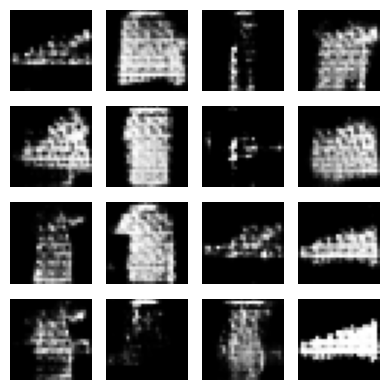

In [2]:
import matplotlib.pyplot as plt
import numpy as np

predictions = generator(seed, training=False)

fig = plt.figure(figsize=(4, 4))
for i in range(predictions.shape[0]):
    plt.subplot(4, 4, i + 1)
    img = (predictions[i, :, :, 0] + 1.0) * 127.5  # обратно к [0, 255]
    plt.imshow(img.numpy().astype("uint8"), cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

---

## **Задание №2.** Обучите генератор воспризводить примитивные изображения по заданному условию (Conditional Generative Adversarial Nets (CGAN)).



(На вход генератора подается вектор случайного шума и метка класса - на выходе должно получиться изображение, соответствующее данному классу)



Датасет выберите по желанию. ([Пример №1](https://www.kaggle.com/datasets/andrewmvd/medical-mnist), [Пример №2](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/fashion_mnist/load_data#example), [Пример №3](https://www.kaggle.com/datasets/sagyamthapa/handwritten-math-symbols))

In [3]:


(train_images, train_labels), (_, _) = tf.keras.datasets.fashion_mnist.load_data()
train_images = train_images.astype("float32")
train_images = (train_images - 127.5) / 127.5
train_images = np.expand_dims(train_images, axis=-1)

NUM_CLASSES = 10
BUFFER_SIZE = train_images.shape[0]
BATCH_SIZE = 256

train_dataset = (tf.data.Dataset.from_tensor_slices((train_images, train_labels))
                 .shuffle(BUFFER_SIZE)
                 .batch(BATCH_SIZE, drop_remainder=True))

NOISE_DIM = 100

# Условный генератор: на вход шум и метка класса
def make_cgan_generator():
    noise_input = tf.keras.layers.Input(shape=(NOISE_DIM,))
    label_input = tf.keras.layers.Input(shape=(), dtype='int32')

    # Встраивание метки
    x = tf.keras.layers.Embedding(NUM_CLASSES, 50)(label_input)
    x = tf.keras.layers.Dense(NOISE_DIM)(x)
    x = tf.keras.layers.LeakyReLU()(x)

    # Комбинируем шум и вектор метки
    combined = tf.keras.layers.Concatenate()([noise_input, x])

    x = tf.keras.layers.Dense(7*7*256, use_bias=False)(combined)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU()(x)

    x = tf.keras.layers.Reshape((7, 7, 256))(x)

    x = tf.keras.layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same',
                                        use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU()(x)

    x = tf.keras.layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same',
                                        use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU()(x)

    out_img = tf.keras.layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same',
                                              use_bias=False, activation='tanh')(x)

    return tf.keras.Model([noise_input, label_input], out_img)

# Условный дискриминатор: на вход изображение и метка
def make_cgan_discriminator():
    img_input = tf.keras.layers.Input(shape=(28, 28, 1))
    label_input = tf.keras.layers.Input(shape=(), dtype='int32')

    x = tf.keras.layers.Embedding(NUM_CLASSES, 50)(label_input)
    x = tf.keras.layers.Dense(28*28)(x)
    x = tf.keras.layers.Reshape((28, 28, 1))(x)

    # Конкатенируем карту метки с изображением по каналам
    combined = tf.keras.layers.Concatenate(axis=-1)([img_input, x])

    y = tf.keras.layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same')(combined)
    y = tf.keras.layers.LeakyReLU()(y)
    y = tf.keras.layers.Dropout(0.3)(y)

    y = tf.keras.layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same')(y)
    y = tf.keras.layers.LeakyReLU()(y)
    y = tf.keras.layers.Dropout(0.3)(y)

    y = tf.keras.layers.Flatten()(y)
    out = tf.keras.layers.Dense(1)(y)

    return tf.keras.Model([img_input, label_input], out)

generator_cgan = make_cgan_generator()
discriminator_cgan = make_cgan_discriminator()

cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

gen_optimizer = tf.keras.optimizers.Adam(1e-4)
disc_optimizer = tf.keras.optimizers.Adam(1e-4)

EPOCHS = 30
NUM_EXAMPLES_TO_GENERATE = 16

# фиксированный набор меток для демонстрации
demo_labels = tf.constant([i % NUM_CLASSES for i in range(NUM_EXAMPLES_TO_GENERATE)], dtype=tf.int32)
demo_noise = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, NOISE_DIM])

@tf.function
def train_step_cgan(images, labels):
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])
    random_labels = tf.random.uniform([BATCH_SIZE], minval=0, maxval=NUM_CLASSES, dtype=tf.int32)

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator_cgan([noise, random_labels], training=True)

        real_output = discriminator_cgan([images, labels], training=True)
        fake_output = discriminator_cgan([generated_images, random_labels], training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator_cgan.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator_cgan.trainable_variables)

    gen_optimizer.apply_gradients(zip(gradients_of_generator, generator_cgan.trainable_variables))
    disc_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator_cgan.trainable_variables))
    return gen_loss, disc_loss

def train_cgan(dataset, epochs):
    for epoch in range(epochs):
        gen_losses = []
        disc_losses = []
        for images_batch, labels_batch in dataset:
            g_loss, d_loss = train_step_cgan(images_batch, labels_batch)
            gen_losses.append(g_loss)
            disc_losses.append(d_loss)
        print(f"Epoch {epoch + 1}/{epochs} - "
              f"gen_loss={tf.reduce_mean(gen_losses):.4f}, "
              f"disc_loss={tf.reduce_mean(disc_losses):.4f}")

    generator_cgan.save_weights("cgan_fashion_mnist_generator.weights.h5")
    discriminator_cgan.save_weights("cgan_fashion_mnist_discriminator.weights.h5")

train_cgan(train_dataset, EPOCHS)

Epoch 1/30 - gen_loss=0.7833, disc_loss=1.1075
Epoch 2/30 - gen_loss=0.9431, disc_loss=1.1885
Epoch 3/30 - gen_loss=0.8781, disc_loss=1.2346
Epoch 4/30 - gen_loss=0.8876, disc_loss=1.2694
Epoch 5/30 - gen_loss=0.7620, disc_loss=1.3741
Epoch 6/30 - gen_loss=0.8290, disc_loss=1.2634
Epoch 7/30 - gen_loss=0.8091, disc_loss=1.3117
Epoch 8/30 - gen_loss=0.8725, disc_loss=1.2222
Epoch 9/30 - gen_loss=0.7930, disc_loss=1.3516
Epoch 10/30 - gen_loss=0.7907, disc_loss=1.2969
Epoch 11/30 - gen_loss=0.8170, disc_loss=1.2931
Epoch 12/30 - gen_loss=0.8363, disc_loss=1.2633
Epoch 13/30 - gen_loss=0.9255, disc_loss=1.1817
Epoch 14/30 - gen_loss=0.9546, disc_loss=1.1894
Epoch 15/30 - gen_loss=0.9224, disc_loss=1.2047
Epoch 16/30 - gen_loss=0.9105, disc_loss=1.2303
Epoch 17/30 - gen_loss=0.8489, disc_loss=1.2564
Epoch 18/30 - gen_loss=0.9665, disc_loss=1.1889
Epoch 19/30 - gen_loss=1.0181, disc_loss=1.1271
Epoch 20/30 - gen_loss=1.0322, disc_loss=1.0794
Epoch 21/30 - gen_loss=1.1802, disc_loss=1.0110
E

### **Демонстрация сгенерированных изображений:**

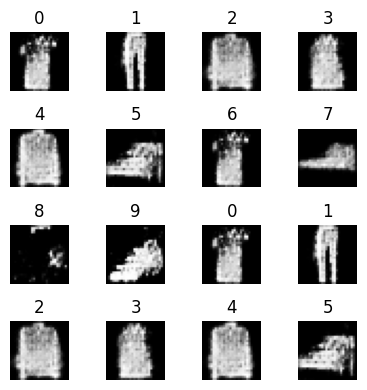

In [4]:
predictions = generator_cgan([demo_noise, demo_labels], training=False)

fig = plt.figure(figsize=(4, 4))
for i in range(predictions.shape[0]):
    plt.subplot(4, 4, i + 1)
    img = (predictions[i, :, :, 0] + 1.0) * 127.5
    plt.imshow(img.numpy().astype("uint8"), cmap='gray')
    plt.title(int(demo_labels[i]))
    plt.axis('off')

plt.tight_layout()
plt.show()

---

## **Задание №3.** Обучите генератор колоризировать изображения из выбранного Вами датасета (можете использовать датасет из работы №6, в которой Вы решали аналогичную задачу).

In [5]:
!pip install -q kaggle

!kaggle datasets download -d rahmasleam/flowers-dataset --unzip -p /content/flowers

!ls /content/flowers/flowers

Dataset URL: https://www.kaggle.com/datasets/rahmasleam/flowers-dataset
License(s): apache-2.0
100% 219M/219M [00:02<00:00, 110MB/s]

ls: cannot access '/content/flowers/flowers': No such file or directory


In [6]:
IMG_SIZE = 128
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

data_dir = "/content/flowers/flower_photos"

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    label_mode=None,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

def prepare_pair(rgb_batch):
    # Нормализация к [-1, 1]
    rgb = tf.cast(rgb_batch, tf.float32) / 127.5 - 1.0
    # Перевод в серый (1 канал в [-1,1])
    gray = tf.image.rgb_to_grayscale(rgb)
    return gray, rgb

train_pairs = (train_ds
               .map(prepare_pair, num_parallel_calls=AUTOTUNE)
               .prefetch(AUTOTUNE))

# Генератор
def make_colorization_generator():
    inputs = tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

    # Encoder
    x1 = tf.keras.layers.Conv2D(64, 4, strides=2, padding="same")(inputs)
    x1 = tf.keras.layers.LeakyReLU(0.2)(x1)

    x2 = tf.keras.layers.Conv2D(128, 4, strides=2, padding="same")(x1)
    x2 = tf.keras.layers.BatchNormalization()(x2)
    x2 = tf.keras.layers.LeakyReLU(0.2)(x2)

    x3 = tf.keras.layers.Conv2D(256, 4, strides=2, padding="same")(x2)
    x3 = tf.keras.layers.BatchNormalization()(x3)
    x3 = tf.keras.layers.LeakyReLU(0.2)(x3)

    x4 = tf.keras.layers.Conv2D(512, 4, strides=2, padding="same")(x3)
    x4 = tf.keras.layers.BatchNormalization()(x4)
    x4 = tf.keras.layers.LeakyReLU(0.2)(x4)

    # Bottleneck
    b = tf.keras.layers.Conv2D(512, 4, strides=2, padding="same")(x4)
    b = tf.keras.layers.ReLU()(b)

    # Decoder
    d1 = tf.keras.layers.Conv2DTranspose(512, 4, strides=2, padding="same")(b)
    d1 = tf.keras.layers.BatchNormalization()(d1)
    d1 = tf.keras.layers.ReLU()(d1)
    d1 = tf.keras.layers.Concatenate()([d1, x4])

    d2 = tf.keras.layers.Conv2DTranspose(256, 4, strides=2, padding="same")(d1)
    d2 = tf.keras.layers.BatchNormalization()(d2)
    d2 = tf.keras.layers.ReLU()(d2)
    d2 = tf.keras.layers.Concatenate()([d2, x3])

    d3 = tf.keras.layers.Conv2DTranspose(128, 4, strides=2, padding="same")(d2)
    d3 = tf.keras.layers.BatchNormalization()(d3)
    d3 = tf.keras.layers.ReLU()(d3)
    d3 = tf.keras.layers.Concatenate()([d3, x2])

    d4 = tf.keras.layers.Conv2DTranspose(64, 4, strides=2, padding="same")(d3)
    d4 = tf.keras.layers.BatchNormalization()(d4)
    d4 = tf.keras.layers.ReLU()(d4)
    d4 = tf.keras.layers.Concatenate()([d4, x1])

    # Выход RGB (3 канала в [-1,1] через tanh)
    out = tf.keras.layers.Conv2DTranspose(3, 4, strides=2, padding="same",
                                          activation="tanh")(d4)

    return tf.keras.Model(inputs, out)

#  Дискриминатор
def make_colorization_discriminator():
    inp_gray = tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    inp_rgb = tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = tf.keras.layers.Concatenate(axis=-1)([inp_gray, inp_rgb])

    x = tf.keras.layers.Conv2D(64, 4, strides=2, padding="same")(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.Conv2D(128, 4, strides=2, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.Conv2D(256, 4, strides=2, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.Conv2D(512, 4, strides=1, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    out = tf.keras.layers.Conv2D(1, 4, strides=1, padding="same")(x)
    return tf.keras.Model([inp_gray, inp_rgb], out)

gen_col = make_colorization_generator()
disc_col = make_colorization_discriminator()

bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)

LAMBDA_L1 = 100.0

def generator_loss_col(disc_generated_output, gen_output, target):
    adv_loss = bce(tf.ones_like(disc_generated_output), disc_generated_output)
    l1_loss = tf.reduce_mean(tf.abs(target - gen_output))
    return adv_loss + LAMBDA_L1 * l1_loss

def discriminator_loss_col(disc_real_output, disc_generated_output):
    real_loss = bce(tf.ones_like(disc_real_output), disc_real_output)
    fake_loss = bce(tf.zeros_like(disc_generated_output), disc_generated_output)
    return real_loss + fake_loss

gen_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
disc_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

EPOCHS = 20

@tf.function
def train_step_colorization(gray, rgb):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_rgb = gen_col(gray, training=True)

        disc_real = disc_col([gray, rgb], training=True)
        disc_fake = disc_col([gray, gen_rgb], training=True)

        gen_loss = generator_loss_col(disc_fake, gen_rgb, rgb)
        disc_loss = discriminator_loss_col(disc_real, disc_fake)

    gen_gradients = gen_tape.gradient(gen_loss, gen_col.trainable_variables)
    disc_gradients = disc_tape.gradient(disc_loss, disc_col.trainable_variables)

    gen_opt.apply_gradients(zip(gen_gradients, gen_col.trainable_variables))
    disc_opt.apply_gradients(zip(disc_gradients, disc_col.trainable_variables))
    return gen_loss, disc_loss

for epoch in range(EPOCHS):
    gen_losses = []
    disc_losses = []
    for gray_batch, rgb_batch in train_pairs:
        g_loss, d_loss = train_step_colorization(gray_batch, rgb_batch)
        gen_losses.append(g_loss)
        disc_losses.append(d_loss)
    print(f"Epoch {epoch + 1}/{EPOCHS} - "
          f"gen_loss={tf.reduce_mean(gen_losses):.4f}, "
          f"disc_loss={tf.reduce_mean(disc_losses):.4f}")

gen_col.save_weights("colorization_flowers_generator.weights.h5")
disc_col.save_weights("colorization_flowers_discriminator.weights.h5")

Found 3670 files.
Epoch 1/20 - gen_loss=24.5943, disc_loss=0.8570
Epoch 2/20 - gen_loss=22.5482, disc_loss=0.8633
Epoch 3/20 - gen_loss=21.8256, disc_loss=0.8876
Epoch 4/20 - gen_loss=21.1707, disc_loss=0.8878
Epoch 5/20 - gen_loss=20.7126, disc_loss=0.9108
Epoch 6/20 - gen_loss=20.1795, disc_loss=0.9030
Epoch 7/20 - gen_loss=19.5201, disc_loss=0.9486
Epoch 8/20 - gen_loss=18.5615, disc_loss=0.9851
Epoch 9/20 - gen_loss=17.6687, disc_loss=0.9840
Epoch 10/20 - gen_loss=16.5802, disc_loss=1.0218
Epoch 11/20 - gen_loss=15.7063, disc_loss=1.0471
Epoch 12/20 - gen_loss=14.7713, disc_loss=1.0499
Epoch 13/20 - gen_loss=13.9088, disc_loss=1.0902
Epoch 14/20 - gen_loss=13.2745, disc_loss=1.0998
Epoch 15/20 - gen_loss=12.6443, disc_loss=1.1198
Epoch 16/20 - gen_loss=12.1925, disc_loss=1.1281
Epoch 17/20 - gen_loss=11.7611, disc_loss=1.1472
Epoch 18/20 - gen_loss=11.4032, disc_loss=1.1434
Epoch 19/20 - gen_loss=10.9924, disc_loss=1.1375
Epoch 20/20 - gen_loss=10.8111, disc_loss=1.1165


### **Демонстрация сгенерированных изображений:**

Found 3670 files.


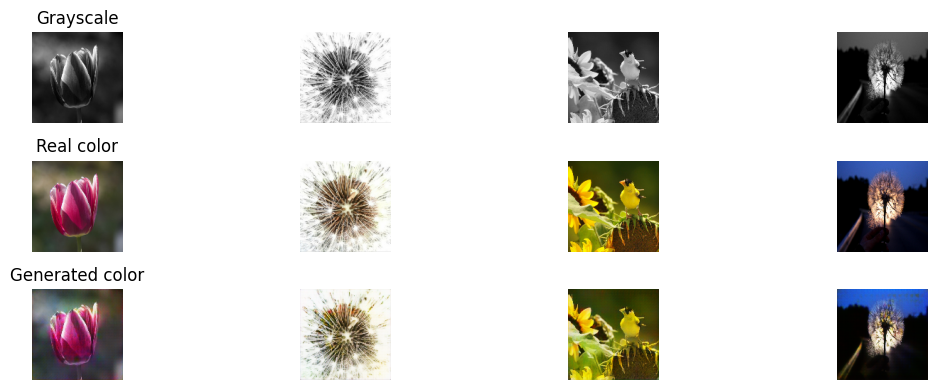

In [7]:
# перезагрузим датасет на небольшое количество батчей
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    label_mode=None,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=4
)

test_pairs = test_ds.map(prepare_pair)

for gray_batch, rgb_batch in test_pairs.take(1):
    gen_rgb = gen_col(gray_batch, training=False)

    gray_np = (gray_batch + 1.0) / 2.0
    rgb_np = (rgb_batch + 1.0) / 2.0
    gen_np = (gen_rgb + 1.0) / 2.0

    plt.figure(figsize=(12, 4))
    for i in range(gray_batch.shape[0]):
        # серое
        plt.subplot(3, gray_batch.shape[0], i + 1)
        plt.imshow(gray_np[i, :, :, 0], cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.title("Grayscale")

        # истинное RGB
        plt.subplot(3, gray_batch.shape[0], gray_batch.shape[0] + i + 1)
        plt.imshow(rgb_np[i])
        plt.axis("off")
        if i == 0:
            plt.title("Real color")

        # сгенерированное RGB
        plt.subplot(3, gray_batch.shape[0], 2*gray_batch.shape[0] + i + 1)
        plt.imshow(gen_np[i])
        plt.axis("off")
        if i == 0:
            plt.title("Generated color")

    plt.tight_layout()
    plt.show()

---

## **Задание №4.** Обучите генератор воспроизводить изображения из выбранного Вами датасета (pix2pix).



---
Примеры таких датасетов представлены на сайтах [kaggle.com](https://www.kaggle.com/search?q=pix2pix+in%3Adatasets+datasetFileTypes%3Ajpg+datasetFileTypes%3Apng) и [efrosgans.eecs.berkeley.edu*](http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/).

**\*Калифорнийский университет Беркли (UC Berkeley) внесён в реестр организаций, деятельность которых признана нежелательной в России.**


---

In [8]:
!kaggle datasets download -d vikramtiwari/pix2pix-dataset --unzip -p /content/pix2pix_data
!ls /content/pix2pix_data

Dataset URL: https://www.kaggle.com/datasets/vikramtiwari/pix2pix-dataset
License(s): unknown
100% 2.40G/2.40G [00:36<00:00, 70.6MB/s]

cityscapes  edges2shoes  facades  maps


Train: 400 файлов
Val:   100 файлов
Epoch   1/50 — gen_loss=38.5781, disc_loss=1.0121
Epoch   2/50 — gen_loss=38.6770, disc_loss=0.4223
Epoch   3/50 — gen_loss=39.2186, disc_loss=0.4245
Epoch   4/50 — gen_loss=39.1561, disc_loss=0.4917
Epoch   5/50 — gen_loss=39.2972, disc_loss=0.4858
Epoch   6/50 — gen_loss=39.1098, disc_loss=0.5542
Epoch   7/50 — gen_loss=38.8409, disc_loss=0.5332
Epoch   8/50 — gen_loss=38.6527, disc_loss=0.5858
Epoch   9/50 — gen_loss=38.2239, disc_loss=0.5467
Epoch  10/50 — gen_loss=37.8945, disc_loss=0.6241


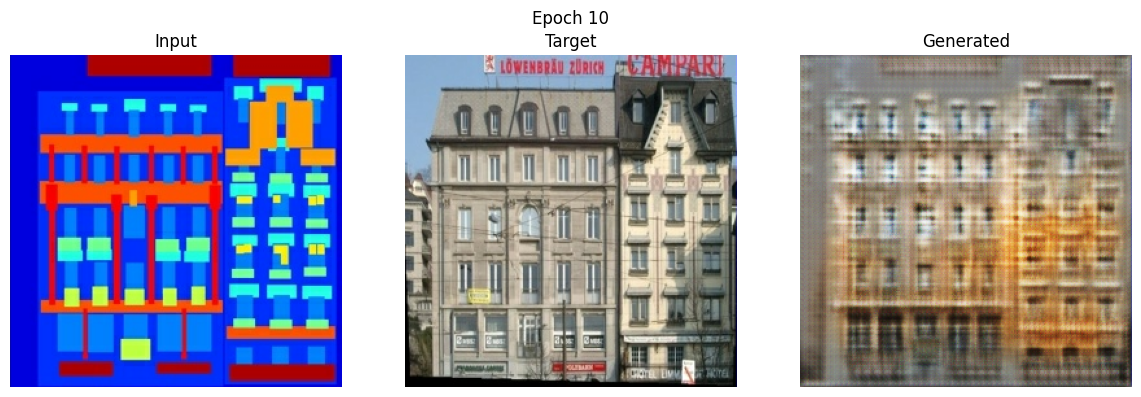

Epoch  11/50 — gen_loss=37.3506, disc_loss=0.6423
Epoch  12/50 — gen_loss=36.6327, disc_loss=0.6268
Epoch  13/50 — gen_loss=36.3883, disc_loss=0.6781
Epoch  14/50 — gen_loss=36.1278, disc_loss=0.7318
Epoch  15/50 — gen_loss=35.4020, disc_loss=0.6441
Epoch  16/50 — gen_loss=34.2217, disc_loss=0.7055
Epoch  17/50 — gen_loss=33.7052, disc_loss=0.7302
Epoch  18/50 — gen_loss=33.4299, disc_loss=0.7142
Epoch  19/50 — gen_loss=32.6221, disc_loss=0.7964
Epoch  20/50 — gen_loss=31.9842, disc_loss=0.7983


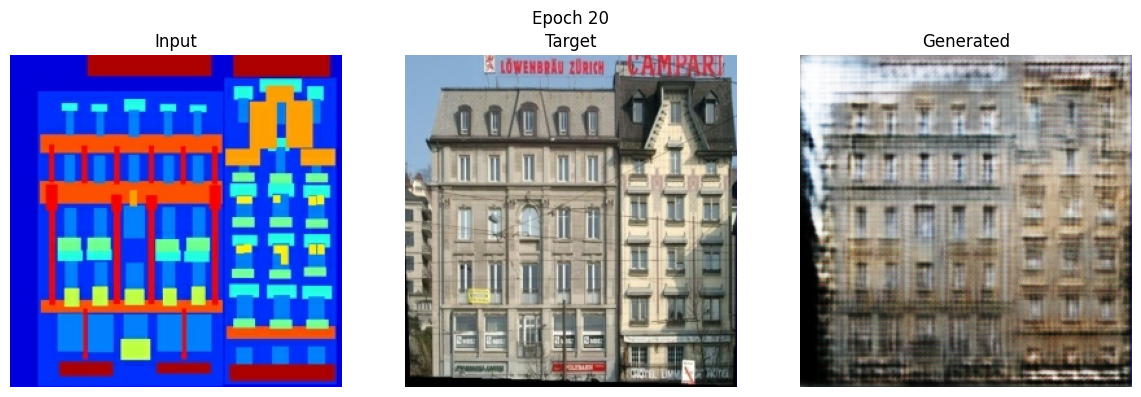

Epoch  21/50 — gen_loss=31.5015, disc_loss=0.7971
Epoch  22/50 — gen_loss=30.6588, disc_loss=0.8204
Epoch  23/50 — gen_loss=30.1596, disc_loss=0.8396
Epoch  24/50 — gen_loss=29.6141, disc_loss=0.8649
Epoch  25/50 — gen_loss=29.1800, disc_loss=0.8264
Epoch  26/50 — gen_loss=28.4758, disc_loss=0.8322
Epoch  27/50 — gen_loss=28.4062, disc_loss=0.8971
Epoch  28/50 — gen_loss=27.5185, disc_loss=0.8393
Epoch  29/50 — gen_loss=27.3897, disc_loss=0.8666
Epoch  30/50 — gen_loss=26.9157, disc_loss=0.8319


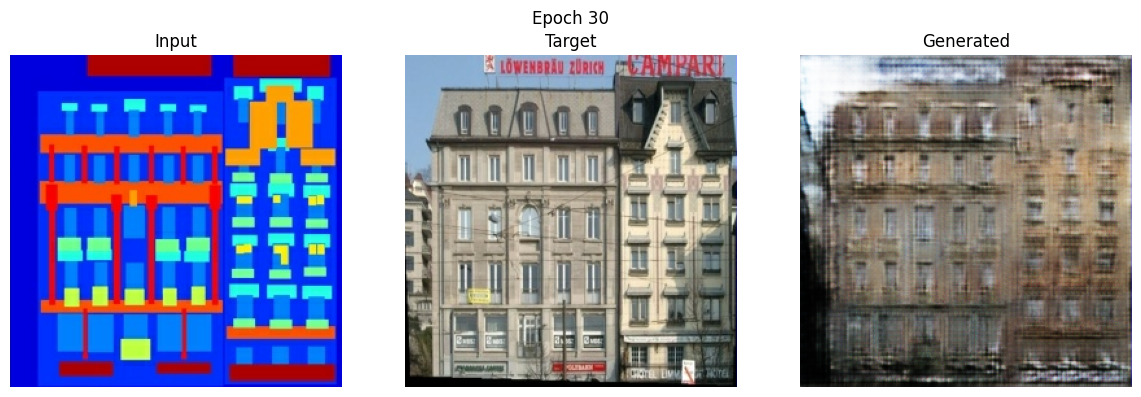

Epoch  31/50 — gen_loss=26.4754, disc_loss=0.8683
Epoch  32/50 — gen_loss=26.0564, disc_loss=0.9200
Epoch  33/50 — gen_loss=25.5932, disc_loss=0.8907
Epoch  34/50 — gen_loss=25.2471, disc_loss=0.8920
Epoch  35/50 — gen_loss=24.9919, disc_loss=0.8681
Epoch  36/50 — gen_loss=24.5090, disc_loss=0.8737
Epoch  37/50 — gen_loss=24.3173, disc_loss=0.8745
Epoch  38/50 — gen_loss=23.9586, disc_loss=0.8574
Epoch  39/50 — gen_loss=23.4641, disc_loss=0.9540
Epoch  40/50 — gen_loss=23.4060, disc_loss=0.8936


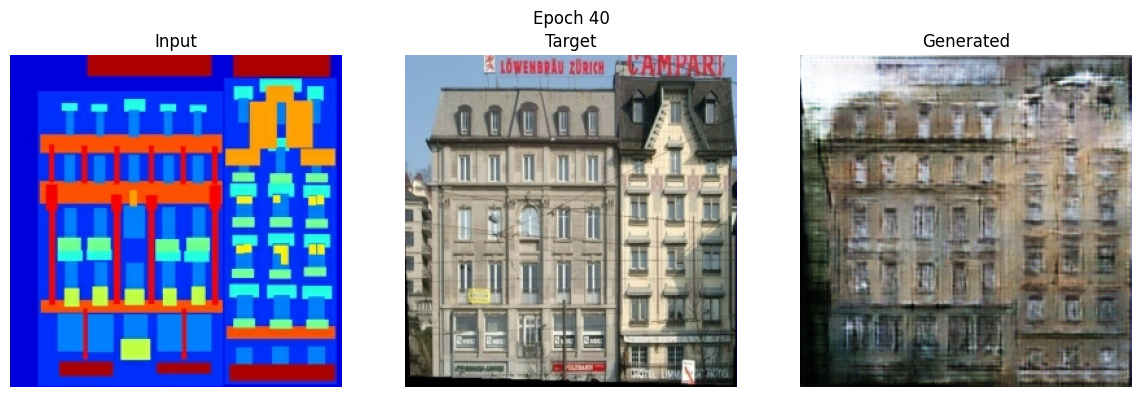

Epoch  41/50 — gen_loss=22.9026, disc_loss=0.8754
Epoch  42/50 — gen_loss=22.7085, disc_loss=0.8786
Epoch  43/50 — gen_loss=22.5941, disc_loss=0.9201
Epoch  44/50 — gen_loss=22.2147, disc_loss=0.9065
Epoch  45/50 — gen_loss=21.5794, disc_loss=0.8914
Epoch  46/50 — gen_loss=21.3655, disc_loss=0.9189
Epoch  47/50 — gen_loss=21.3277, disc_loss=0.8859
Epoch  48/50 — gen_loss=20.9964, disc_loss=0.8789
Epoch  49/50 — gen_loss=20.9178, disc_loss=0.9144
Epoch  50/50 — gen_loss=20.8144, disc_loss=0.8661


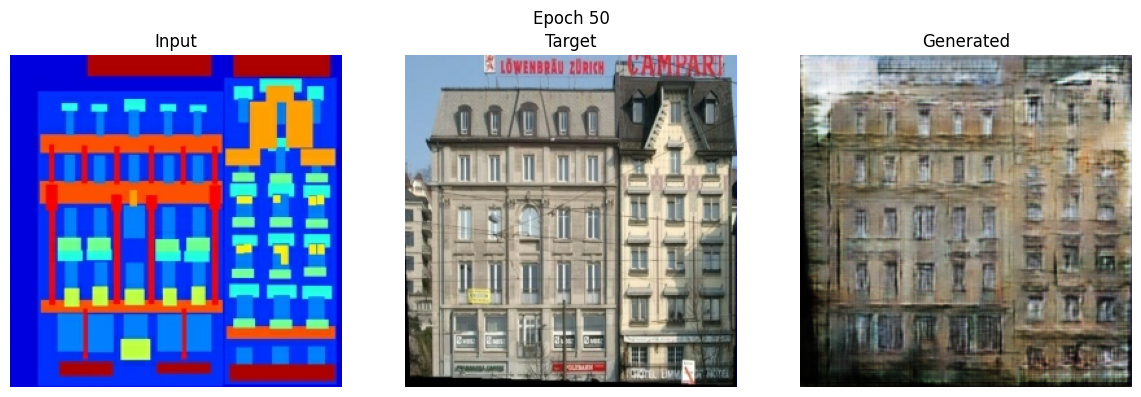

Веса сохранены.


In [12]:
import glob
IMG_SIZE = 256
BATCH_SIZE = 4
AUTOTUNE = tf.data.AUTOTUNE

# Генератор
def make_pix2pix_generator():
    def downsample(filters, apply_batchnorm=True):
        result = tf.keras.Sequential()
        result.add(tf.keras.layers.Conv2D(
            filters, 4, strides=2, padding='same', use_bias=False))
        if apply_batchnorm:
            result.add(tf.keras.layers.BatchNormalization())
        result.add(tf.keras.layers.LeakyReLU())
        return result

    def upsample(filters, apply_dropout=False):
        result = tf.keras.Sequential()
        result.add(tf.keras.layers.Conv2DTranspose(
            filters, 4, strides=2, padding='same', use_bias=False))
        result.add(tf.keras.layers.BatchNormalization())
        if apply_dropout:
            result.add(tf.keras.layers.Dropout(0.5))
        result.add(tf.keras.layers.ReLU())
        return result

    inputs = tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    down_stack = [
        downsample(64,  apply_batchnorm=False),  # (128, 128, 64)
        downsample(128),                          # (64, 64, 128)
        downsample(256),                          # (32, 32, 256)
        downsample(512),                          # (16, 16, 512)
        downsample(512),                          # (8, 8, 512)
        downsample(512),                          # (4, 4, 512)
        downsample(512),                          # (2, 2, 512)
        downsample(512),                          # (1, 1, 512)
    ]

    up_stack = [
        upsample(512, apply_dropout=True),  # (2, 2, 512)
        upsample(512, apply_dropout=True),  # (4, 4, 512)
        upsample(512, apply_dropout=True),  # (8, 8, 512)
        upsample(512),                      # (16, 16, 512)
        upsample(256),                      # (32, 32, 256)
        upsample(128),                      # (64, 64, 128)
        upsample(64),                       # (128, 128, 64)
    ]

    x = inputs
    skips = []
    for down in down_stack:
        x = down(x)
        skips.append(x)

    skips = list(reversed(skips[:-1]))

    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = tf.keras.layers.Concatenate()([x, skip])

    last = tf.keras.layers.Conv2DTranspose(
        3, 4, strides=2, padding='same', activation='tanh')
    outputs = last(x)

    return tf.keras.Model(inputs=inputs, outputs=outputs)


# Дискриминатор
def make_pix2pix_discriminator():
    inp = tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_image')
    tar = tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='target_image')

    x = tf.keras.layers.Concatenate()([inp, tar])

    x = tf.keras.layers.Conv2D(64, 4, strides=2, padding='same')(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.Conv2D(128, 4, strides=2, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.Conv2D(256, 4, strides=2, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.Conv2D(512, 4, strides=1, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    out = tf.keras.layers.Conv2D(1, 4, strides=1, padding='same')(x)

    return tf.keras.Model(inputs=[inp, tar], outputs=out)


gen_pix  = make_pix2pix_generator()
disc_pix = make_pix2pix_discriminator()

bce      = tf.keras.losses.BinaryCrossentropy(from_logits=True)
LAMBDA   = 100.0

def generator_loss(disc_generated_output, gen_output, target):
    adv_loss = bce(tf.ones_like(disc_generated_output), disc_generated_output)
    l1_loss  = tf.reduce_mean(tf.abs(target - gen_output))
    return adv_loss + LAMBDA * l1_loss

def discriminator_loss(disc_real_output, disc_generated_output):
    real_loss = bce(tf.ones_like(disc_real_output),      disc_real_output)
    fake_loss = bce(tf.zeros_like(disc_generated_output), disc_generated_output)
    return real_loss + fake_loss

gen_opt  = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
disc_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)


# Один шаг обучения
@tf.function
def train_step(input_image, target):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_output = gen_pix(input_image, training=True)

        disc_real      = disc_pix([input_image, target],     training=True)
        disc_generated = disc_pix([input_image, gen_output], training=True)

        gen_loss  = generator_loss(disc_generated, gen_output, target)
        disc_loss = discriminator_loss(disc_real, disc_generated)

    gen_grads  = gen_tape.gradient(gen_loss,  gen_pix.trainable_variables)
    disc_grads = disc_tape.gradient(disc_loss, disc_pix.trainable_variables)

    gen_opt.apply_gradients(zip(gen_grads,  gen_pix.trainable_variables))
    disc_opt.apply_gradients(zip(disc_grads, disc_pix.trainable_variables))

    return gen_loss, disc_loss


def generate_images(model, test_input, target, epoch):
    prediction = model(test_input, training=False)
    plt.figure(figsize=(12, 4))
    display_list = [test_input[0], target[0], prediction[0]]
    titles = ["Input", "Target", "Generated"]
    for i, (img, title) in enumerate(zip(display_list, titles)):
        plt.subplot(1, 3, i + 1)
        plt.title(title)
        plt.imshow((img + 1.0) / 2.0)
        plt.axis("off")
    plt.suptitle(f"Epoch {epoch}")
    plt.tight_layout()
    plt.show()


#  Цикл обучения


DATASET_NAME = "facades/facades"  # замени на maps / edges2shoes / cityscapes
train_dir = f"/content/pix2pix_data/{DATASET_NAME}/train"
val_dir   = f"/content/pix2pix_data/{DATASET_NAME}/val"

def load_image_pair(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.cast(img, tf.float32)

    w  = tf.shape(img)[1]
    w2 = w // 2

    input_img  = img[:, w2:, :]
    target_img = img[:, :w2, :]

    input_img  = tf.image.resize(input_img,  [IMG_SIZE, IMG_SIZE])
    target_img = tf.image.resize(target_img, [IMG_SIZE, IMG_SIZE])

    input_img  = input_img  / 127.5 - 1.0
    target_img = target_img / 127.5 - 1.0

    return input_img, target_img

def make_dataset(file_list, shuffle=True):
    if len(file_list) == 0:
        raise ValueError(f"Нет файлов! Проверьте путь к датасету.")
    ds = tf.data.Dataset.from_tensor_slices(file_list)
    if shuffle:
        ds = ds.shuffle(len(file_list))
    ds = ds.map(load_image_pair, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE, drop_remainder=True)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_files = glob.glob(os.path.join(train_dir, "*.jpg")) + \
              glob.glob(os.path.join(train_dir, "*.png"))
val_files   = glob.glob(os.path.join(val_dir,   "*.jpg")) + \
              glob.glob(os.path.join(val_dir,   "*.png"))

print(f"Train: {len(train_files)} файлов")
print(f"Val:   {len(val_files)} файлов")

train_ds = make_dataset(train_files, shuffle=True)
val_ds   = make_dataset(val_files,   shuffle=False)

EPOCHS = 50

sample_input, sample_target = next(iter(val_ds))

for epoch in range(1, EPOCHS + 1):
    gen_losses  = []
    disc_losses = []

    for inp_batch, tar_batch in train_ds:
        g_loss, d_loss = train_step(inp_batch, tar_batch)
        gen_losses.append(float(g_loss))
        disc_losses.append(float(d_loss))

    mean_g = sum(gen_losses)  / len(gen_losses)
    mean_d = sum(disc_losses) / len(disc_losses)
    print(f"Epoch {epoch:>3}/{EPOCHS} — gen_loss={mean_g:.4f}, disc_loss={mean_d:.4f}")

    # Визуализация каждые 10 эпох
    if epoch % 10 == 0:
        generate_images(gen_pix, sample_input[:1], sample_target[:1], epoch)

gen_pix.save_weights("pix2pix_generator.weights.h5")
disc_pix.save_weights("pix2pix_discriminator.weights.h5")
print("Веса сохранены.")

### **Демонстрация сгенерированных изображений:**

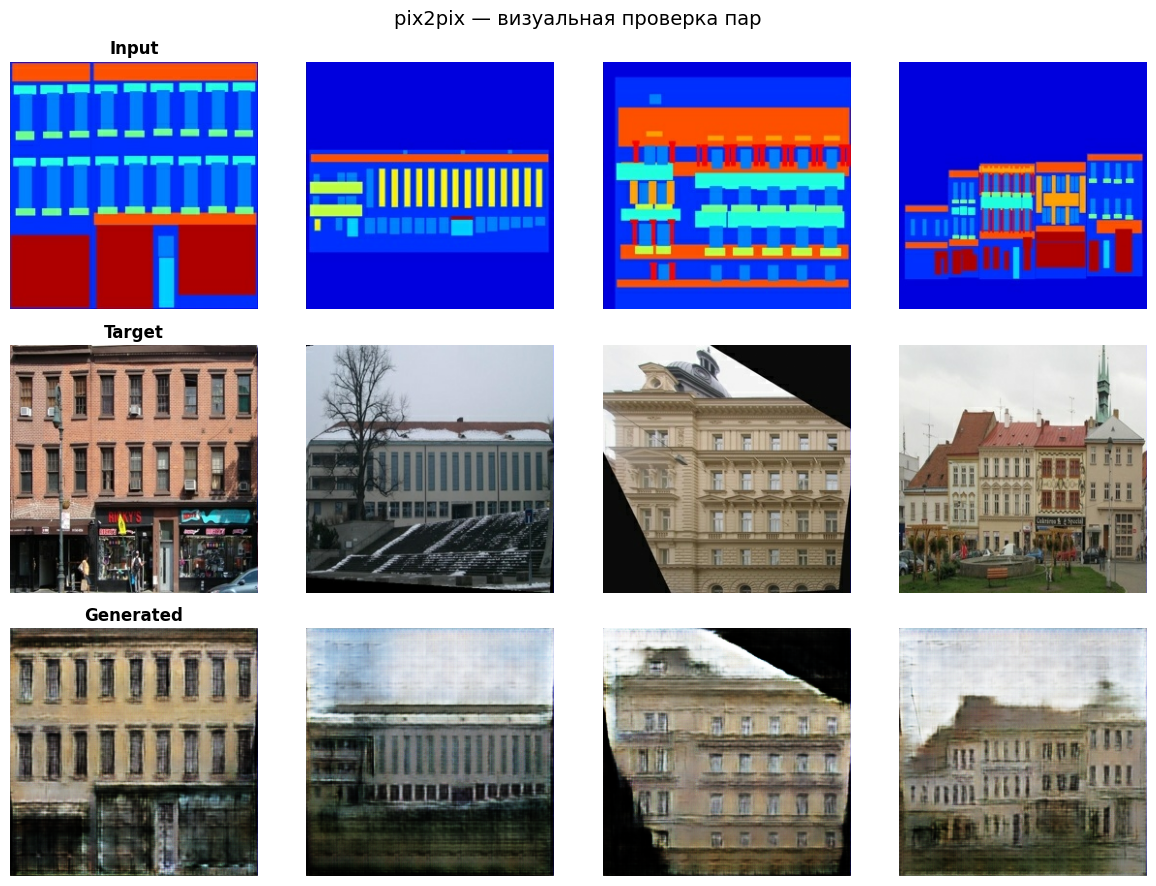

In [13]:
import matplotlib.pyplot as plt

# Убедись, что gen_pix уже создан и (опционально) загружен:
# gen_pix = make_pix2pix_generator()
# gen_pix.load_weights("pix2pix_generator.weights.h5")

for inp_batch, tar_batch in train_ds.take(1):
    n = min(4, BATCH_SIZE)

    gen_batch = gen_pix(inp_batch[:n], training=False)

    inp_np = (inp_batch[:n] + 1.0) / 2.0
    tar_np = (tar_batch[:n] + 1.0) / 2.0
    gen_np = (gen_batch      + 1.0) / 2.0

    fig, axes = plt.subplots(3, n, figsize=(n * 3, 9))

    row_titles = ["Input", "Target", "Generated"]

    for i in range(n):
        for row, img in enumerate([inp_np[i], tar_np[i], gen_np[i]]):
            axes[row, i].imshow(img)
            axes[row, i].axis("off")
            if i == 0:
                axes[row, i].set_title(row_titles[row], fontsize=12, fontweight="bold")

    plt.suptitle("pix2pix — визуальная проверка пар", fontsize=14)
    plt.tight_layout()
    plt.show()